# Analisis de prompts -- pipeline SIN malla (axial / planar)

Notebook de analisis para comparar variantes de prompt (`axis_v00`, `axis_v01`, ...,
`plane_v00`, ...) evaluadas con `Mapping/estimate_symmetry_no_mesh.py` +
`Mapping/evaluate.py` (metodos `triangulation` / `triangulation_multiplane`).

Lee los CSV combinados que genera `Mapping/compare_results_no_mesh.py --csv-dir ...`
(uno por symmetry_type, bajo `results/experiments_DD_MM_YYYY/`), los concatena entre
todas las carpetas de fecha que existan, y arma tablas de ranking + plots.

**Todas las corridas usan las mismas columnas** dentro de cada symmetry_type (las que
escribe `evaluate.py::write_csv`), asi que agregar un prompt nuevo es simplemente
correr los 3 comandos (copia -> estimate_symmetry_no_mesh -> evaluate) y volver a
correr `compare_results_no_mesh.py`; este notebook no necesita cambios.

Ver `docs/pipeline_sin_malla.md`, `docs/metricas_evaluacion.md` y
`Mapping/compare_results_no_mesh.py` para el detalle de cada metrica.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT   = Path(r"C:\Users\HP\Desktop\Seminario de Tesis I\Symmetry-Detection-Using-Multimodal-Vision-Language-Models")
RESULTS_ROOT = REPO_ROOT / "results"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

plt.rcParams.update({
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 120,
})

## 1. Carga: concatena todos los `experiments_*` disponibles

Cada corrida de `compare_results_no_mesh.py --csv-dir ../results` escribe en una
carpeta `experiments_DD_MM_YYYY/` nueva (una por dia). Si volviste a evaluar el
mismo prompt+n_views otro dia, nos quedamos con la fila mas reciente
(`drop_duplicates(keep="last")` sobre `(experiment, method, n_views)`, ordenado
por fecha de carpeta).

In [2]:
def _folder_date(p: Path):
    # experiments_DD_MM_YYYY -> tupla ordenable (YYYY, MM, DD)
    try:
        d, m, y = p.name.removeprefix("experiments_").split("_")
        return (int(y), int(m), int(d))
    except Exception:
        return (0, 0, 0)


def load_nomesh_csvs(symmetry_type: str) -> pd.DataFrame:
    """Concatena <symmetry_type>_nomesh_comparison.csv de todas las carpetas
    experiments_*/, ordenadas por fecha, y deduplica quedandose con lo mas nuevo."""
    exp_dirs = sorted(RESULTS_ROOT.glob("experiments_*"), key=_folder_date)
    frames = []
    for d in exp_dirs:
        csv_path = d / f"{symmetry_type}_nomesh_comparison.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df["_source_folder"] = d.name
            frames.append(df)
    if not frames:
        raise SystemExit(
            f"[error] No se encontro ningun {symmetry_type}_nomesh_comparison.csv bajo {RESULTS_ROOT}. "
            "Corre antes: python Mapping/compare_results_no_mesh.py --symmetry-type "
            f"{symmetry_type} --renders-root ../data/renders --csv-dir ../results --no-plots"
        )
    combined = pd.concat(frames, ignore_index=True)
    key = ["experiment", "method", "n_views"]
    combined = combined.sort_values("_source_folder").drop_duplicates(key, keep="last")
    return combined.drop(columns="_source_folder").reset_index(drop=True)


def enrich(df: pd.DataFrame) -> pd.DataFrame:
    """Agrega columnas derivadas del nombre de experimento, utiles para agrupar/filtrar:
    - base_prompt: 'axis_v00_1_nomesh' -> 'v00'
    - is_v1: True si el prompt es la variante '_1' (mejorada)
    - is_flow: 'flowB'/'flowC' si el experimento viene de Flow B/C, sino None
    """
    df = df.copy()

    def parse(exp: str) -> tuple[str, bool, str | None]:
        stem = exp.removesuffix("_nomesh")
        flow = next((f for f in ("flowB", "flowC") if stem.endswith(f"_{f}")), None)
        if flow:
            stem = stem[: -(len(flow) + 1)]
        is_v1 = stem.endswith("_1")
        if is_v1:
            stem = stem[:-2]
        base = stem.split("_", 1)[1] if "_" in stem else stem  # 'axis_v00' -> 'v00'
        return base, is_v1, flow

    parsed = df["experiment"].apply(parse)
    df["base_prompt"] = parsed.apply(lambda t: t[0])
    df["is_v1"]       = parsed.apply(lambda t: t[1])
    df["flow"]        = parsed.apply(lambda t: t[2])
    return df

In [3]:
df_axis  = enrich(load_nomesh_csvs("axis_sym"))
df_plane = enrich(load_nomesh_csvs("plane_sym"))

print(f"axis_sym : {df_axis['experiment'].nunique()} experimentos, {len(df_axis)} filas (experiment x n_views)")
print(f"plane_sym: {df_plane['experiment'].nunique()} experimentos, {len(df_plane)} filas")
print("\nExperimentos axis_sym :", sorted(df_axis['experiment'].unique()))
print("Experimentos plane_sym:", sorted(df_plane['experiment'].unique()))

axis_sym : 6 experimentos, 18 filas (experiment x n_views)
plane_sym: 6 experimentos, 18 filas

Experimentos axis_sym : ['axis_v00_1_nomesh', 'axis_v00_nomesh', 'axis_v04_1_nomesh', 'axis_v04_nomesh', 'axis_v05_1_nomesh', 'axis_v05_nomesh']
Experimentos plane_sym: ['plane_v00_1_nomesh', 'plane_v00_nomesh', 'plane_v02_1_nomesh', 'plane_v02_nomesh', 'plane_v05_1_nomesh', 'plane_v05_nomesh']


## 2. Inventario rapido: que columnas trae cada symmetry_type

`axis_sym` (metodo `triangulation`) trae metricas angulares (angular_error, AUC,
precision@theta). `plane_sym` (metodo `triangulation_multiplane`) trae recall/precision
sobre el conjunto de planos GT -- son metricas distintas por diseno (ver
`Mapping/evaluate.py::write_csv`), no comparables entre si.

In [4]:
def inventory(df: pd.DataFrame, label: str) -> None:
    print(f"--- {label} ---")
    print(f"columnas: {list(df.columns)}")
    print(f"n_views disponibles: {sorted(df['n_views'].unique())}")
    print(f"metodo(s): {sorted(df['method'].unique())}")
    print()

inventory(df_axis, "axis_sym")
inventory(df_plane, "plane_sym")

--- axis_sym ---
columnas: ['experiment', 'method', 'n_views', 'n_total', 'n_objects', 'angular_error_mean', 'angular_error_median', 'angular_error_std', 'translation_error_mean', 'translation_error_median', 'translation_error_std', 'translation_error_normalized_mean', 'translation_error_normalized_median', 'auc_angular', 'n_points_mean', 'precision_5deg', 'precision_10deg', 'precision_15deg', 'sde_ref_mean', 'sde_ref_min', 'sde_ref_max', 'base_prompt', 'is_v1', 'flow']
n_views disponibles: [np.int64(6), np.int64(14), np.int64(26)]
metodo(s): ['triangulation']

--- plane_sym ---
columnas: ['experiment', 'method', 'n_views', 'n_total', 'n_objects', 'n_planes_predicted_mean', 'n_true_planes_mean', 'n_planes_matched_mean', 'recall_planes_mean', 'precision_planes_mean', 'sde_ref_mean', 'sde_ref_min', 'sde_ref_max', 'f1_ref', 'f1_ref_hungarian', 'base_prompt', 'is_v1', 'flow']
n_views disponibles: [np.int64(6), np.int64(14), np.int64(26)]
metodo(s): ['triangulation_multiplane']



## 3. Ranking -- eje (`angular_error_mean` ascendente = mejor)

In [5]:
AXIS_COLS = ["experiment", "base_prompt", "is_v1", "flow", "n_views", "n_objects",
             "angular_error_mean", "angular_error_median", "auc_angular",
             "precision_5deg", "precision_10deg", "precision_15deg",
             "translation_error_mean"]
AXIS_COLS = [c for c in AXIS_COLS if c in df_axis.columns]


def best_per_experiment(df: pd.DataFrame, sort_col: str, ascending: bool,
                        cols: list[str]) -> pd.DataFrame:
    """Para cada 'experiment', se queda con la fila (n_views) que mejor puntua
    en sort_col -- 'cual es el mejor resultado que logro este prompt, en
    cualquier cantidad de vistas'."""
    idx = (df.sort_values(sort_col, ascending=ascending)
             .groupby("experiment")
             .head(1)
             .index)
    return df.loc[idx, cols].sort_values(sort_col, ascending=ascending).reset_index(drop=True)


print("Ranking por experimento (mejor n_views de cada uno), ordenado por angular_error_mean:")
best_per_experiment(df_axis, "angular_error_mean", ascending=True, cols=AXIS_COLS)

Ranking por experimento (mejor n_views de cada uno), ordenado por angular_error_mean:


,experiment,base_prompt,is_v1,flow,n_views,n_objects,angular_error_mean,angular_error_median,auc_angular,precision_5deg,precision_10deg,precision_15deg,translation_error_mean
0,axis_v05_1_nomesh,v05,True,None,26,831,57.3560,60.5323,0.1039,0.0035,0.0129,0.0353,0.461498
1,axis_v05_nomesh,v05,False,None,26,830,57.6749,60.8479,0.1021,0.0035,0.0141,0.0353,0.451286
2,axis_v04_nomesh,v04,False,None,6,831,57.6775,59.8444,0.1001,0.0059,0.0165,0.0424,0.294693
3,axis_v00_1_nomesh,v00,True,None,26,828,57.7794,61.1501,0.1002,0.0035,0.0129,0.0365,0.603244
4,axis_v04_1_nomesh,v04,True,None,26,829,57.8352,60.0594,0.0989,0.0035,0.0176,0.0424,0.237305
5,axis_v00_nomesh,v00,False,None,6,793,59.0896,61.8778,0.0935,0.0059,0.0153,0.0365,0.503985


### 3.1 Tabla completa (todos los n_views) -- eje

In [6]:
(df_axis[AXIS_COLS]
   .sort_values(["experiment", "n_views"])
   .style.background_gradient(subset=["angular_error_mean"], cmap="RdYlGn_r")
         .background_gradient(subset=[c for c in ["auc_angular", "precision_10deg"] if c in AXIS_COLS], cmap="RdYlGn"))

,experiment,base_prompt,is_v1,flow,n_views,n_objects,angular_error_mean,angular_error_median,auc_angular,precision_5deg,precision_10deg,precision_15deg,translation_error_mean
0,axis_v00_1_nomesh,v00,True,None,6,791,59.585800,62.481400,0.092100,0.003500,0.012900,0.037600,1.049133
15,axis_v00_1_nomesh,v00,True,None,14,789,59.298900,62.556900,0.094300,0.003500,0.014100,0.032900,0.670072
14,axis_v00_1_nomesh,v00,True,None,26,828,57.779400,61.150100,0.100200,0.003500,0.012900,0.036500,0.603244
13,axis_v00_nomesh,v00,False,None,6,793,59.089600,61.877800,0.093500,0.005900,0.015300,0.036500,0.503985
12,axis_v00_nomesh,v00,False,None,14,745,61.716300,66.473800,0.090500,0.004700,0.022400,0.045900,0.309435
11,axis_v00_nomesh,v00,False,None,26,781,59.910800,62.698100,0.095200,0.003500,0.014100,0.036500,0.283895
10,axis_v04_1_nomesh,v04,True,None,6,824,58.502500,60.535600,0.093500,0.005900,0.014100,0.043500,0.452423
9,axis_v04_1_nomesh,v04,True,None,14,809,59.388100,62.160500,0.094000,0.005900,0.015300,0.043500,0.216855
8,axis_v04_1_nomesh,v04,True,None,26,829,57.835200,60.059400,0.098900,0.003500,0.017600,0.042400,0.237305
7,axis_v04_nomesh,v04,False,None,6,831,57.677500,59.844400,0.100100,0.005900,0.016500,0.042400,0.294693


### 3.2 Ablation: v0 vs v1 (eje)

Compara, para cada `base_prompt` y `n_views`, el prompt original vs. su version `_1`
mejorada -- responde "valio la pena iterar el prompt?".

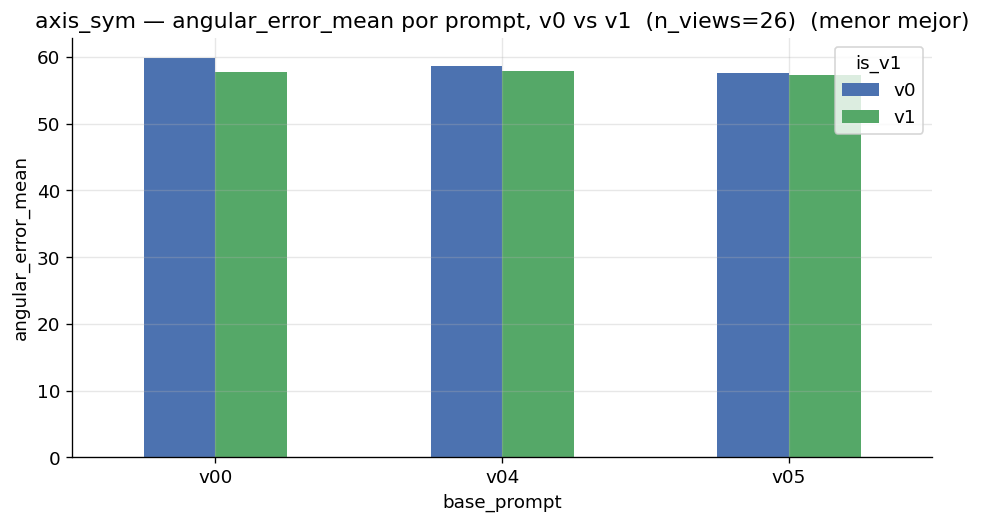

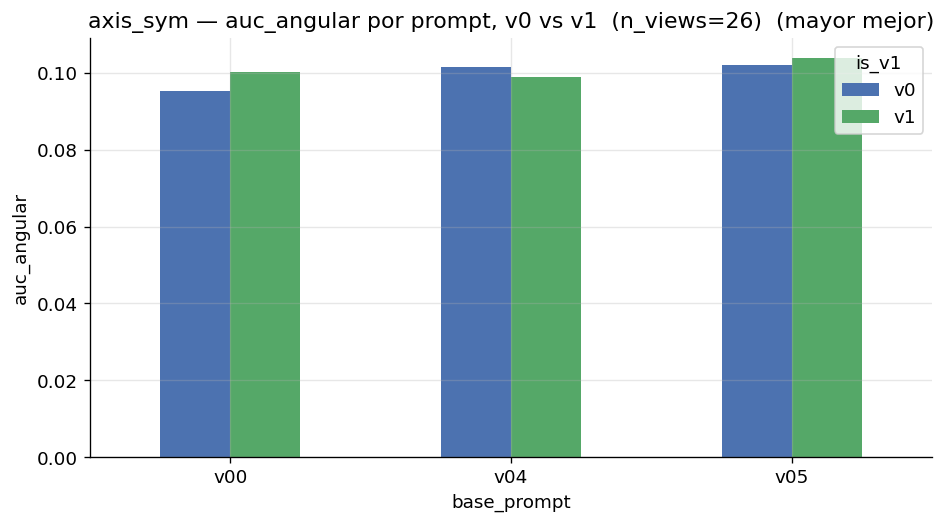

In [7]:
def plot_ablation_bar(df: pd.DataFrame, metric: str, symmetry_label: str,
                      higher_better: bool, n_views: int | None = None) -> None:
    """Barras agrupadas v0 vs v1, una por base_prompt. Si n_views es None usa
    el mayor n_views disponible para cada experimento (via best row already
    filtered by caller) -- pasar un df ya filtrado a un n_views fijo."""
    sub = df[df["flow"].isna()].copy()  # excluye flowB/flowC de esta comparacion
    if n_views is not None:
        sub = sub[sub["n_views"] == n_views]
    piv = sub.pivot_table(index="base_prompt", columns="is_v1", values=metric)
    piv = piv.rename(columns={False: "v0", True: "v1"}).sort_index()

    ax = piv.plot(kind="bar", figsize=(8, 4.5), color=["#4C72B0", "#55A868"])
    ax.set_ylabel(metric)
    direction = "mayor mejor" if higher_better else "menor mejor"
    title_nv = f"  (n_views={n_views})" if n_views is not None else ""
    ax.set_title(f"{symmetry_label} — {metric} por prompt, v0 vs v1{title_nv}  ({direction})")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


NV_AXIS = sorted(df_axis["n_views"].unique())[-1]  # el mas grande disponible
plot_ablation_bar(df_axis, "angular_error_mean", "axis_sym", higher_better=False, n_views=NV_AXIS)
if "auc_angular" in df_axis.columns:
    plot_ablation_bar(df_axis, "auc_angular", "axis_sym", higher_better=True, n_views=NV_AXIS)

### 3.3 Metricas vs n_views, una linea por experimento (eje)

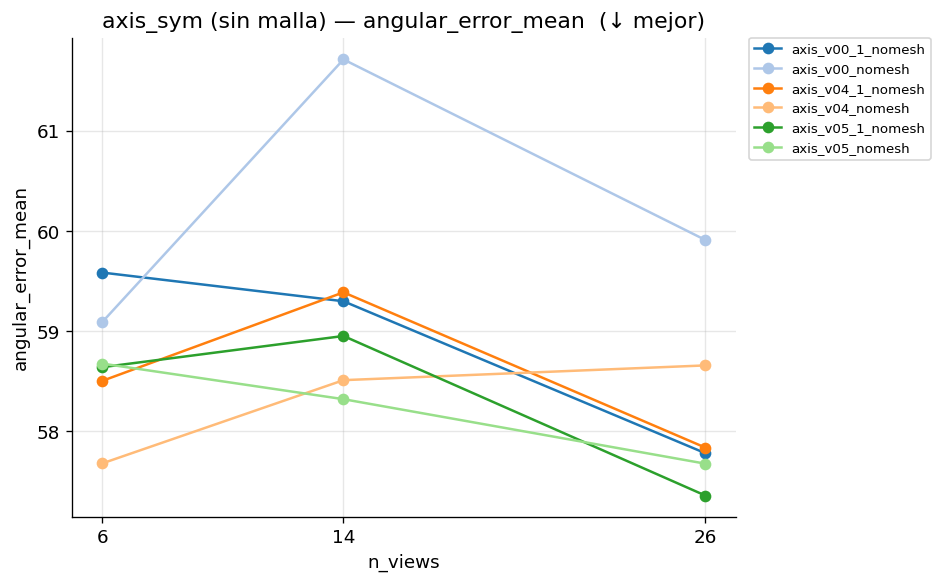

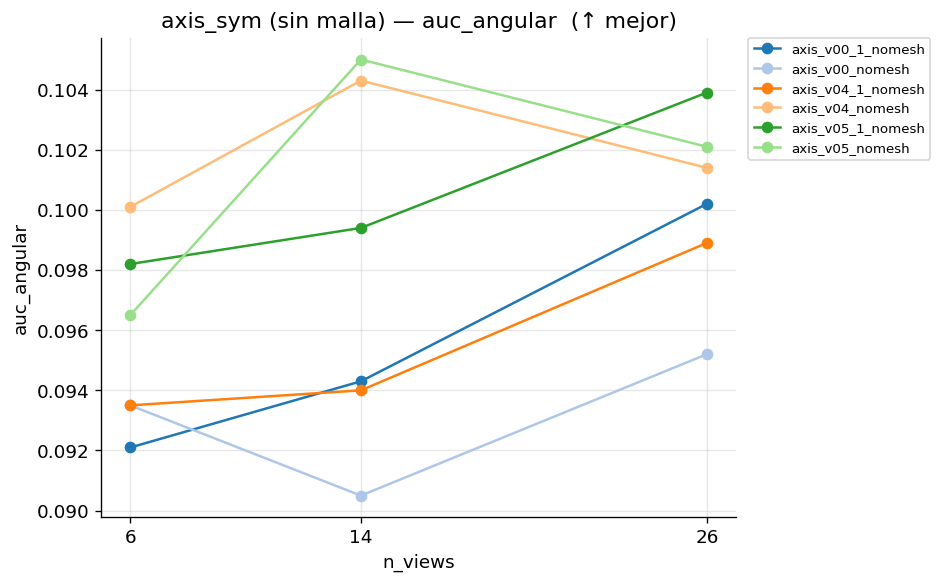

In [8]:
def plot_metric_vs_nviews(df: pd.DataFrame, metric: str, symmetry_label: str,
                          higher_better: bool) -> None:
    if metric not in df.columns:
        print(f"[skip] columna '{metric}' no existe")
        return
    exps   = sorted(df["experiment"].unique())
    cmap   = plt.get_cmap("tab20")
    colors = {e: cmap(i % 20) for i, e in enumerate(exps)}

    fig, ax = plt.subplots(figsize=(8, 5))
    for exp in exps:
        sub = df[df["experiment"] == exp].sort_values("n_views")
        if sub[metric].isna().all():
            continue
        ax.plot(sub["n_views"], sub[metric], marker="o", label=exp, color=colors[exp])
    ax.set_xlabel("n_views")
    ax.set_xticks(sorted(df["n_views"].unique()))
    ax.set_ylabel(metric)
    direction = "↑ mejor" if higher_better else "↓ mejor"
    ax.set_title(f"{symmetry_label} (sin malla) — {metric}  ({direction})")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_vs_nviews(df_axis, "angular_error_mean", "axis_sym", higher_better=False)
plot_metric_vs_nviews(df_axis, "auc_angular", "axis_sym", higher_better=True)

## 4. Ranking -- plano (`recall_planes_mean` / `f1_ref` descendente = mejor)

Distinto criterio que el eje: no hay `angular_error` de un unico plano, sino
recall/precision sobre el conjunto de planos GT (metodo `triangulation_multiplane`).
Ver `Mapping/evaluate.py::evaluate_plane_multiset`.

In [9]:
PLANE_COLS = ["experiment", "base_prompt", "is_v1", "flow", "n_views", "n_objects",
              "n_planes_predicted_mean", "n_true_planes_mean", "n_planes_matched_mean",
              "recall_planes_mean", "precision_planes_mean", "f1_ref", "f1_ref_hungarian"]
PLANE_COLS = [c for c in PLANE_COLS if c in df_plane.columns]

print("Ranking por experimento (mejor n_views de cada uno), ordenado por recall_planes_mean:")
best_per_experiment(df_plane, "recall_planes_mean", ascending=False, cols=PLANE_COLS)

Ranking por experimento (mejor n_views de cada uno), ordenado por recall_planes_mean:


,experiment,base_prompt,is_v1,flow,n_views,n_objects,n_planes_predicted_mean,n_true_planes_mean,n_planes_matched_mean,recall_planes_mean,precision_planes_mean,f1_ref,f1_ref_hungarian
0,plane_v02_nomesh,v02,False,None,14,658,1.9316,1.1809,0.8982,0.8209,0.4764,0.4280,0.4011
1,plane_v00_1_nomesh,v00,True,None,14,582,1.9416,1.1959,0.9021,0.8159,0.4768,0.4424,0.4157
2,plane_v02_1_nomesh,v02,True,None,14,544,1.9467,1.1912,0.8879,0.8076,0.4669,0.4137,0.3881
3,plane_v05_1_nomesh,v05,True,None,14,684,1.9678,1.1827,0.7383,0.6786,0.3801,0.3241,0.3135
4,plane_v00_nomesh,v00,False,None,14,777,1.9704,1.1853,0.6873,0.6347,0.3514,0.2809,0.2773
5,plane_v05_nomesh,v05,False,None,6,839,1.0000,1.1847,0.1979,0.1530,0.1979,0.0787,0.0821


### 4.1 Tabla completa (todos los n_views) -- plano

In [10]:
grad_cols = [c for c in ["recall_planes_mean", "precision_planes_mean", "f1_ref"] if c in PLANE_COLS]
(df_plane[PLANE_COLS]
   .sort_values(["experiment", "n_views"])
   .style.background_gradient(subset=grad_cols, cmap="RdYlGn"))

,experiment,base_prompt,is_v1,flow,n_views,n_objects,n_planes_predicted_mean,n_true_planes_mean,n_planes_matched_mean,recall_planes_mean,precision_planes_mean,f1_ref,f1_ref_hungarian
0,plane_v00_1_nomesh,v00,True,None,6,737,1.000000,1.180500,0.316100,0.293300,0.316100,0.148300,0.160500
15,plane_v00_1_nomesh,v00,True,None,14,582,1.941600,1.195900,0.902100,0.815900,0.476800,0.442400,0.415700
14,plane_v00_1_nomesh,v00,True,None,26,837,2.359600,1.192400,0.875700,0.763000,0.424100,0.171100,0.184200
13,plane_v00_nomesh,v00,False,None,6,833,1.000000,1.194500,0.411800,0.368100,0.411800,0.144000,0.156700
12,plane_v00_nomesh,v00,False,None,14,777,1.970400,1.185300,0.687300,0.634700,0.351400,0.280900,0.277300
11,plane_v00_nomesh,v00,False,None,26,810,2.350600,1.195100,0.675300,0.595100,0.331100,0.133000,0.144200
10,plane_v02_1_nomesh,v02,True,None,6,717,1.000000,1.184100,0.407300,0.368900,0.407300,0.203500,0.220600
9,plane_v02_1_nomesh,v02,True,None,14,544,1.946700,1.191200,0.887900,0.807600,0.466900,0.413700,0.388100
8,plane_v02_1_nomesh,v02,True,None,26,779,2.182300,1.188700,0.843400,0.737300,0.454800,0.206900,0.222800
7,plane_v02_nomesh,v02,False,None,6,792,1.000000,1.186900,0.516400,0.464400,0.516400,0.258800,0.280900


### 4.2 Ablation: v0 vs v1 (plano)

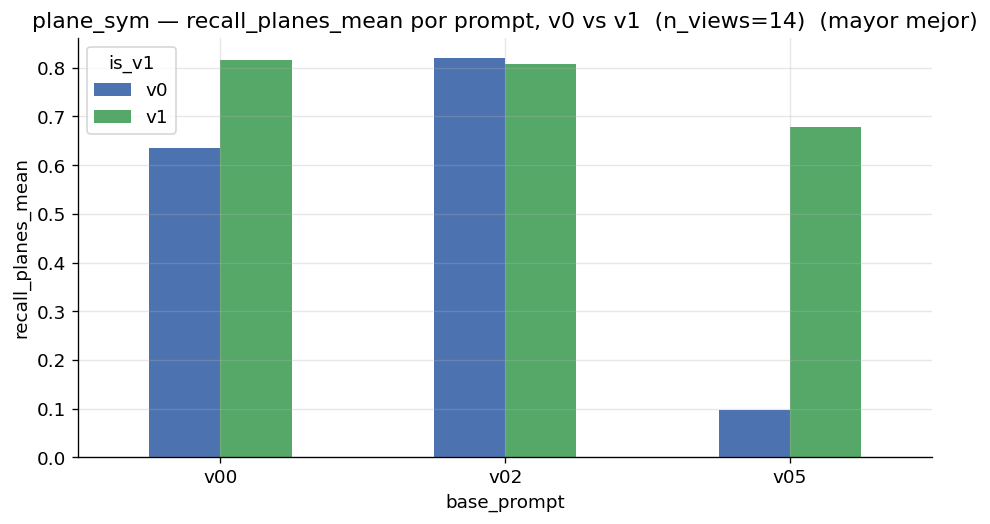

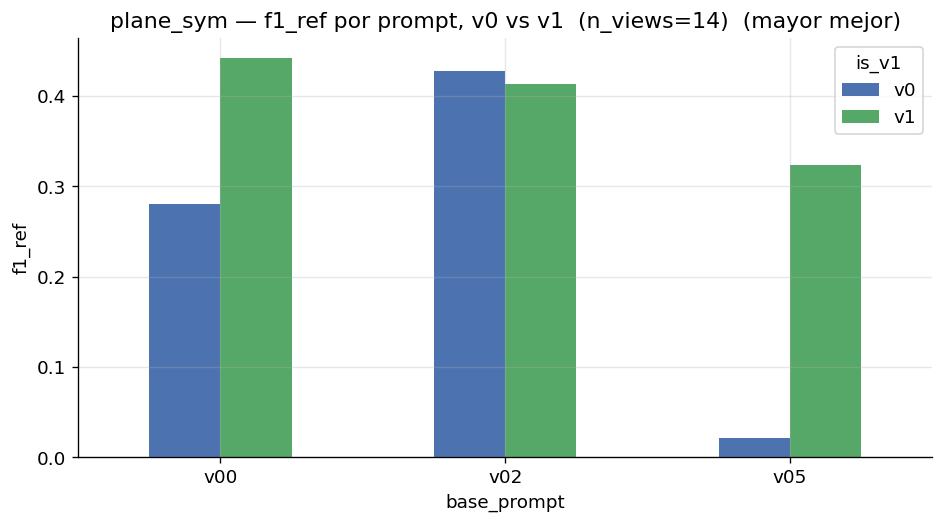

In [11]:
NV_PLANE = 14  # ver seccion 5/6 de la conversacion: n_views=14 fue el optimo empirico, no el maximo
if NV_PLANE not in df_plane["n_views"].unique():
    NV_PLANE = sorted(df_plane["n_views"].unique())[-1]

plot_ablation_bar(df_plane, "recall_planes_mean", "plane_sym", higher_better=True, n_views=NV_PLANE)
if "f1_ref" in df_plane.columns:
    plot_ablation_bar(df_plane, "f1_ref", "plane_sym", higher_better=True, n_views=NV_PLANE)

### 4.3 Metricas vs n_views, una linea por experimento (plano)

Ojo: a diferencia del eje, mas vistas NO siempre mejora recall/precision en el
flujo sin malla (el metodo multi-plano puede sobre-segmentar con muchas vistas) --
esta es la seccion para confirmarlo/refutarlo con cada tanda nueva de prompts.

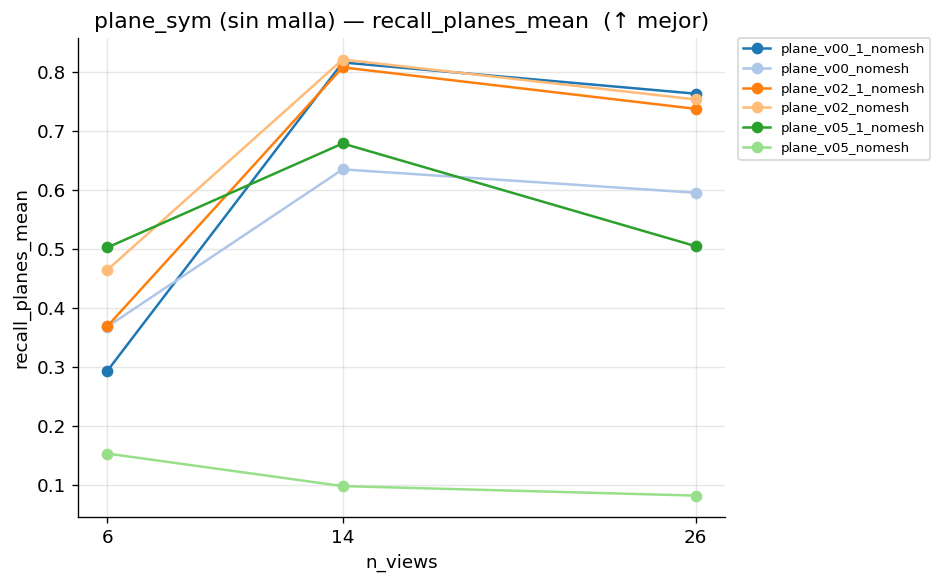

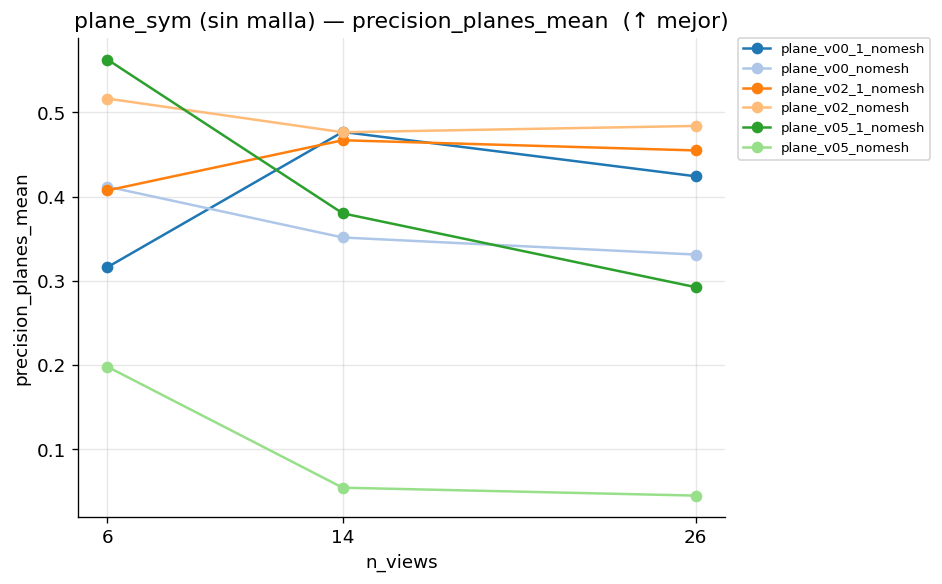

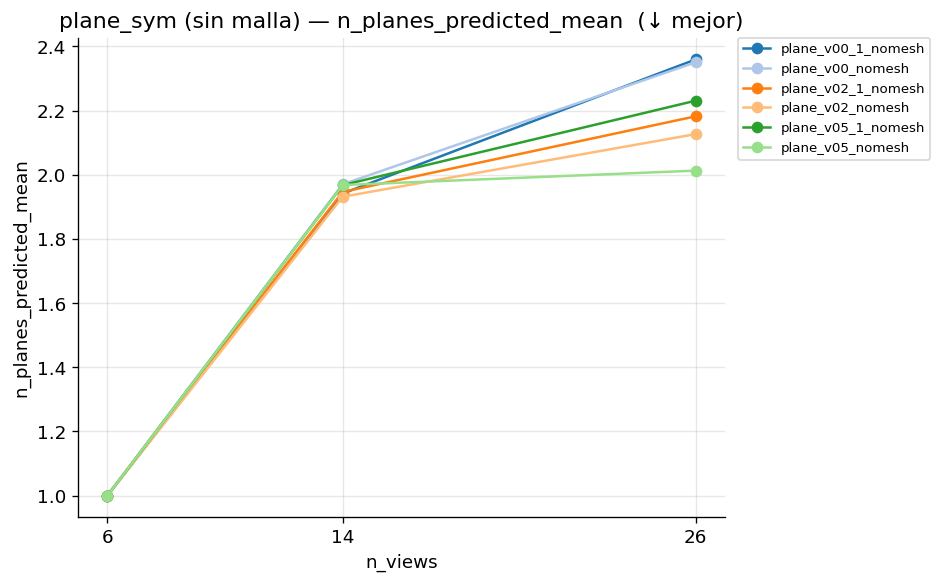

In [12]:
plot_metric_vs_nviews(df_plane, "recall_planes_mean", "plane_sym", higher_better=True)
plot_metric_vs_nviews(df_plane, "precision_planes_mean", "plane_sym", higher_better=True)
plot_metric_vs_nviews(df_plane, "n_planes_predicted_mean", "plane_sym", higher_better=None)

## 5. Filtrar a un subconjunto de prompts nuevos

Cuando agregues una tanda nueva de prompts y quieras comparar SOLO esos (sin el
ruido visual de todos los anteriores), filtra por `experiment` antes de graficar.
Ejemplo:

In [13]:
NUEVOS_AXIS  = []   # ej: ["axis_v06_nomesh", "axis_v07_nomesh"]
NUEVOS_PLANE = []   # ej: ["plane_v06_nomesh"]

if NUEVOS_AXIS:
    sub = df_axis[df_axis["experiment"].isin(NUEVOS_AXIS)]
    display(sub[AXIS_COLS].sort_values(["experiment", "n_views"]))
    plot_metric_vs_nviews(sub, "angular_error_mean", "axis_sym (nuevos)", higher_better=False)

if NUEVOS_PLANE:
    sub = df_plane[df_plane["experiment"].isin(NUEVOS_PLANE)]
    display(sub[PLANE_COLS].sort_values(["experiment", "n_views"]))
    plot_metric_vs_nviews(sub, "recall_planes_mean", "plane_sym (nuevos)", higher_better=True)

## 6. Exportar ranking final

In [14]:
from datetime import date

out_dir = RESULTS_ROOT / f"experiments_{date.today().strftime('%d_%m_%Y')}"
out_dir.mkdir(parents=True, exist_ok=True)

best_per_experiment(df_axis, "angular_error_mean", ascending=True, cols=AXIS_COLS) \
    .to_csv(out_dir / "axis_sym_nomesh_ranking.csv", index=False)
best_per_experiment(df_plane, "recall_planes_mean", ascending=False, cols=PLANE_COLS) \
    .to_csv(out_dir / "plane_sym_nomesh_ranking.csv", index=False)

print(f"Guardado en: {out_dir}")

Guardado en: C:\Users\HP\Desktop\Seminario de Tesis I\Symmetry-Detection-Using-Multimodal-Vision-Language-Models\results\experiments_26_08_2026
